In [2]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
# Load and Preprocess the Dataset

data_dir = "../Data"
categories = ["cancer", "normal"]
img_size = 128

X = []
y = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    label = categories.index(category)

    # walk through subfolders
    for root, dirs, files in os.walk(folder_path):
        for file_name in files:
            file_path = os.path.join(root, file_name)

            try:
                img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    print("Skipping unreadable file:", file_path)
                    continue

                img = cv2.resize(img, (img_size, img_size))
                X.append(img)
                y.append(label)

            except Exception as e:
                print("Error reading:", file_path, e)

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, img_size, img_size, 1)
X = X / 255.0

print("Total images:", len(X))
print("Normal images:", np.sum(y == 1))
print("Cancer images:", np.sum(y == 0))
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Total images: 1097
Normal images: 416
Cancer images: 681
Shape of X: (1097, 128, 128, 1)
Shape of y: (1097,)


In [4]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 877
Testing samples: 220


In [5]:
# Build the CNN Model
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(128,128,1)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.6317 - loss: 0.6364 - val_accuracy: 0.7318 - val_loss: 0.5204
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7560 - loss: 0.5013 - val_accuracy: 0.8227 - val_loss: 0.4352
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8096 - loss: 0.4013 - val_accuracy: 0.8500 - val_loss: 0.3278
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8928 - loss: 0.2765 - val_accuracy: 0.8273 - val_loss: 0.3538
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.9293 - loss: 0.1859 - val_accuracy: 0.9318 - val_loss: 0.1462
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9555 - loss: 0.1287 - val_accuracy: 0.9727 - val_loss: 0.0878
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9749 - loss: 0.0809 - val_accuracy: 0.9818 - val_loss: 0.0904
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9886 - loss: 0.0591 - val_accuracy: 0.9773

In [7]:
# Evaluate Model Performance
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9864 - loss: 0.0352
Test Loss: 0.03517560660839081
Test Accuracy: 0.9863636493682861


In [8]:
# Generate Predictions and Classification Report
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Cancer", "Normal"],
    zero_division=0
))

print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
              precision    recall  f1-score   support

      Cancer       1.00      0.98      0.99       137
      Normal       0.97      1.00      0.98        83

    accuracy                           0.99       220
   macro avg       0.98      0.99      0.99       220
weighted avg       0.99      0.99      0.99       220

[[134   3]
 [  0  83]]


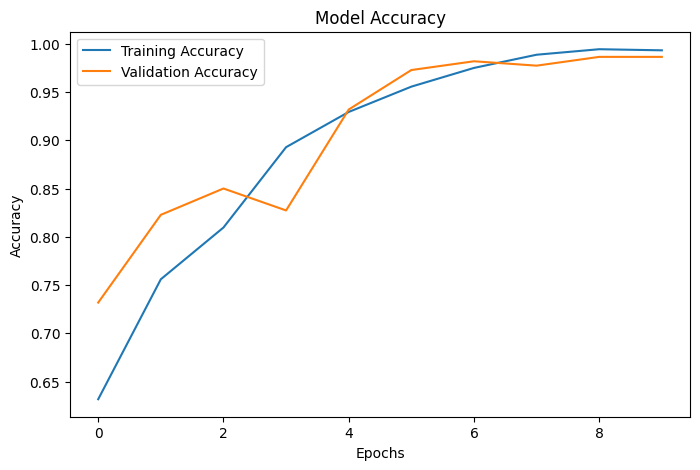

In [9]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.legend()
plt.show()


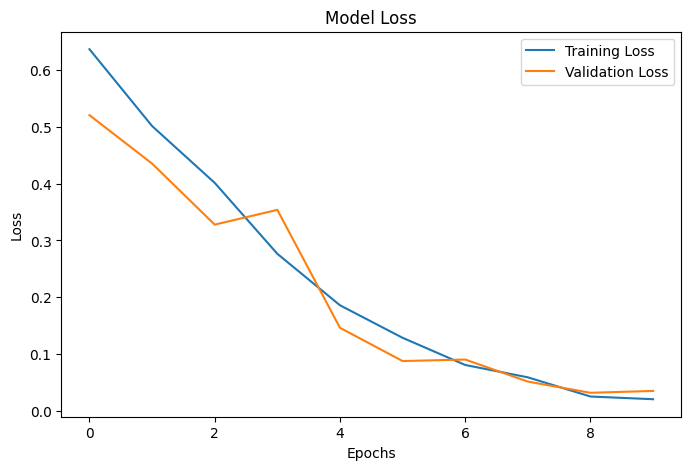

In [10]:
# Plot Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

In [11]:
# Save the trained model
model.save("../models/lung_cancer_cnn_model.keras")

In [12]:
from tensorflow.keras.models import load_model

model = load_model("../models/lung_cancer_cnn_model.keras")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,912,581 (37.81 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


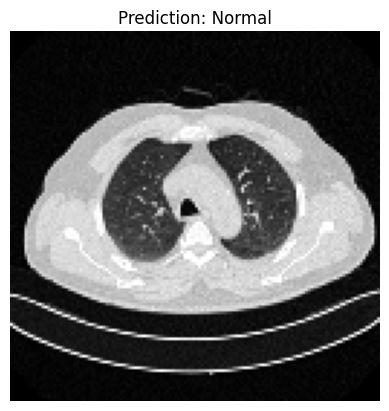

In [13]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Cancer","Normal"]

index = 5

plt.imshow(X_test[index].reshape(128,128), cmap="gray")

prediction = model.predict(X_test[index].reshape(1,128,128,1))

if prediction[0][0] > 0.5:
    predicted_class = "Normal"
else:
    predicted_class = "Cancer"

plt.title("Prediction: " + predicted_class)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


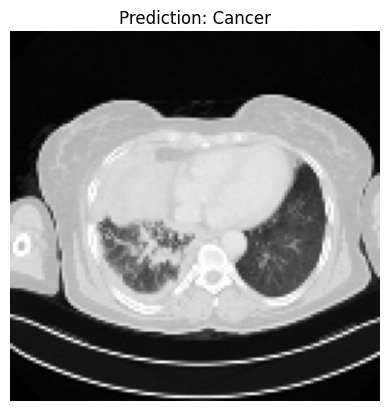

In [14]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Cancer","Normal"]

index = 9

plt.imshow(X_test[index].reshape(128,128), cmap="gray")

prediction = model.predict(X_test[index].reshape(1,128,128,1))

if prediction[0][0] > 0.5:
    predicted_class = "Normal"
else:
    predicted_class = "Cancer"
plt.title("Prediction: " + predicted_class)
plt.axis("off")
plt.show()